Assignment I - Statistical Interpretation & EDA of HDI Dataset

Course: Concepts and Technologies of AI (5CS037)

Student: Pranish Mulmi (2462261)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [28]:
df = pd.read_csv("/content/drive/MyDrive/Concept and Technology of AI/Assignment-1/Human_Development_Index_Dataset.csv", encoding="latin1")

df.columns = df.columns.str.strip().str.lower()
print("Columns:", df.columns.tolist())

Columns: ['unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy', 'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m', 'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m', 'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m', 'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m', 'gender_development', 'gender_inequality', 'secondary_education_f_%', 'secondary_education_m_%', 'seats_in_parliament_f_%', 'seats_in_parliament_m_%', 'labour_participation_f_%', 'labour_participation_m_%', 'co2_emission_tons', 'mat_footprint_percap_tons']


Problem - 1A - Single Year HDI Exploration (Latest Year: 2022)

In [29]:
#1. extract latest year (2022)
years=df['year'].unique()
print("unique years:",years)
hdi_2022_df=df[df['year']==2022].copy()

unique years: [1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022]


In [30]:
#2. data exploration
print(hdi_2022_df.head(10))
print("Shapes:",hdi_2022_df.shape)
print("Data types:",hdi_2022_df.dtypes)

     unnamed: 0 iso3              country  year    hdi  life_expectancy  \
32           33  AFG          Afghanistan  2022  0.462           62.879   
65           66  ALB              Albania  2022  0.789           76.833   
98           99  DZA              Algeria  2022  0.745           77.129   
131         132  AND              Andorra  2022  0.884           83.552   
164         165  AGO               Angola  2022  0.591           61.929   
197         198  ATG  Antigua and Barbuda  2022  0.826           79.236   
230         231  ARG            Argentina  2022  0.849           76.064   
263         264  ARM              Armenia  2022  0.786           73.372   
296         297  AUS            Australia  2022  0.946           83.579   
329         330  AUT              Austria  2022  0.926           82.412   

     pop_millions     hdi_f     hdi_m  life_expec_f  ...  gender_development  \
32      41.128771  0.332443  0.534145        66.213  ...               0.622   
65       2.842

In [31]:
#3. Missing values and cleaning
print("Missing values:",hdi_2022_df.isnull().sum())
for col in['hdi','gross_inc_precap','life_expectancy']:
  if col in hdi_2022_df.columns:
    hdi_2022_df[col]=pd.to_numeric(hdi_2022_df[col],errors='coerce')
hdi_2022_df.drop_duplicates(inplace=True)
hdi_2022_df.dropna(inplace=True)

Missing values: unnamed: 0                    0
iso3                          0
country                       0
year                          0
hdi                           2
life_expectancy               0
pop_millions                  0
hdi_f                        13
hdi_m                        13
life_expec_f                  0
life_expec_m                  0
expec_yr_school               1
expec_yr_school_f             1
expec_yr_school_m             1
mean_yr_school                2
mean_yr_school_f              2
mean_yr_school_m              2
gross_inc_percap              2
gross_inc_percap_f           13
gross_inc_percap_m           13
gender_development           13
gender_inequality            29
secondary_education_f_%      17
secondary_education_m_%      17
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     12
labour_participation_m_%     12
co2_emission_tons             2
mat_footprint_percap_tons    41
dtype: int64


In [32]:
#4. basic statistics
print("HDI Mean:",hdi_2022_df['hdi'].mean())
print("HDI Median:",hdi_2022_df['hdi'].median())
print("HDI Mode:",hdi_2022_df['hdi'].mode())

print("Highest HDI:",hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax()])
print("Lowest HDI:",hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin()])

HDI Mean: 0.7314177215189873
HDI Median: 0.759
HDI Mode: 0     0.394
1     0.487
2     0.517
3     0.540
4     0.548
5     0.550
6     0.601
7     0.698
8     0.760
9     0.763
10    0.764
11    0.765
12    0.766
13    0.780
14    0.802
15    0.820
16    0.855
17    0.875
18    0.879
19    0.915
20    0.926
21    0.927
22    0.942
23    0.946
24    0.950
25    0.952
Name: hdi, dtype: float64
Highest HDI: unnamed: 0                          5610
iso3                                 CHE
country                      Switzerland
year                                2022
hdi                                0.967
life_expectancy                   84.255
pop_millions                    8.740472
hdi_f                           0.949369
hdi_m                           0.977383
life_expec_f                      85.932
life_expec_m                      82.484
expec_yr_school                16.583731
expec_yr_school_f               16.67786
expec_yr_school_m              16.498199
mean_yr_school    

In [33]:
#5. filtering and sorting
if 'gross_inc_precap' in hdi_2022_df.columns:
  high_hdi=hdi_2022_df[hdi_2022_df['hdi']>0.800]
  top10_gni=high_hdi.sort_values(by="gross_inc_precap", ascending=False).head(10)
  print(top10_gni)

In [34]:
#6. add hdi category column
def classify_hdi(val):
  if val<0.550:
    return "low"
  elif val<0.700:
    return "medium"
  elif val<0.800:
    return "high"
  else:
    return "very high"
hdi_2022_df['hdi_category']=hdi_2022_df['hdi'].apply(classify_hdi)
hdi_2022_df.to_csv('/content/drive/MyDrive/Concept and Technology of AI/Assignment-1/hdi_2022_df.csv',index=False)

Problem - 1B - HDI Visualization and Trend Analysis (2020 – 2022)

In [ ]:
#1. data extraction and saving
hdi_2020_2022=df[df['year'].isin([2020,2021,2022])].copy()
# hdi_2020_2022.to_csv("/content/drive/MyDrive/Concept and Technology of AI/Assignment-1/HDI_problem1B.csv",index=False)

print("Filtered dataset shape:", hdi_2020_2022.shape)

Filtered dataset shape: (618, 30)


In [ ]:
#2. data cleaning
print("Missing values:\n", hdi_2020_2022[['hdi','country','year']].isnull().sum())# Check missing values in essential columns

hdi_2020_2022.dropna(subset=['hdi','country','year'], inplace=True)# Drop rows where essential columns are missing

hdi_2020_2022.drop_duplicates(inplace=True)# Remove duplicate rows

for col in ['hdi','gross_inc_percap','life_expectancy']:# Convert numeric columns safely
    if col in hdi_2020_2022.columns:
        hdi_2020_2022[col] = pd.to_numeric(hdi_2020_2022[col], errors='coerce')

hdi_2020_2022.dropna(subset=['hdi'], inplace=True)# Drop rows where conversion produced NaN

hdi_2020_2022['country'] = hdi_2020_2022['country'].str.strip().str.title()# Ensure consistent naming conventions for countries

hdi_2020_2022['year'] = hdi_2020_2022['year'].astype(int)# Ensure year is integer

hdi_2020_2022.to_csv("/content/drive/MyDrive/Concept and Technology of AI/Assignment-1/HDI_problem1B.csv", index=False)# Save cleaned dataset

print("Cleaned dataset shape:", hdi_2020_2022.shape)
print("Sample rows:\n", hdi_2020_2022.head())


Missing values:
 hdi        8
country    0
year       0
dtype: int64
Cleaned dataset shape: (610, 30)
Sample rows:
     unnamed: 0 iso3      country  year    hdi  life_expectancy  pop_millions  \
30          31  AFG  Afghanistan  2020  0.488           62.575     38.972231   
31          32  AFG  Afghanistan  2021  0.473           61.982     40.099462   
32          33  AFG  Afghanistan  2022  0.462           62.879     41.128771   
63          64  ALB      Albania  2020  0.784           76.989      2.866849   
64          65  ALB      Albania  2021  0.785           76.463      2.854710   

       hdi_f     hdi_m  life_expec_f  ...  gender_development  \
30  0.381373  0.548741        65.432  ...               0.695   
31  0.379129  0.528559        65.279  ...               0.717   
32  0.332443  0.534145        66.213  ...               0.622   
63  0.775404  0.793220        79.676  ...               0.978   
64  0.777866  0.792942        79.173  ...               0.981   

    gender_i

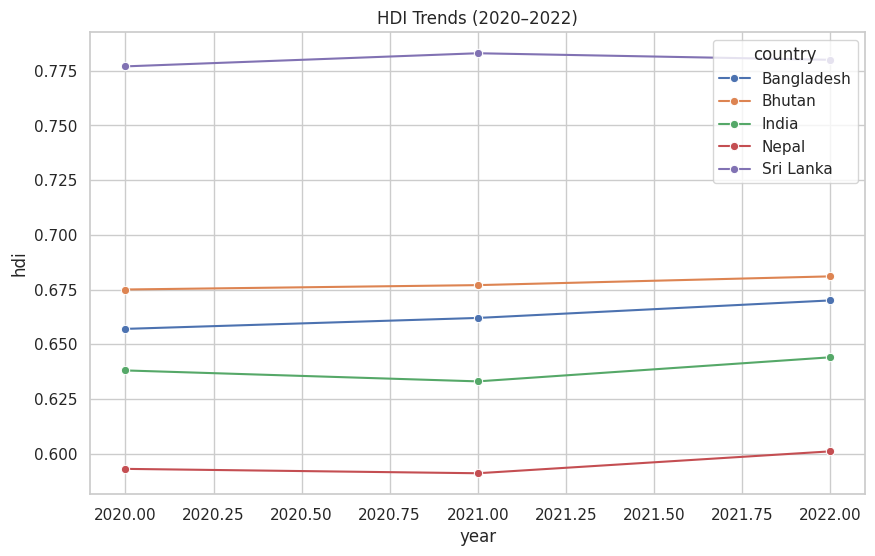

In [37]:
#3. visualization task:
#A. line chart
countries = ["nepal","india","bangladesh","bhutan","sri lanka"]
subset = hdi_2020_2022[hdi_2020_2022['country'].str.lower().isin(countries)]

sns.lineplot(data=subset, x="year", y="hdi", hue="country", marker="o")
plt.title("HDI Trends (2020–2022)")
plt.show()

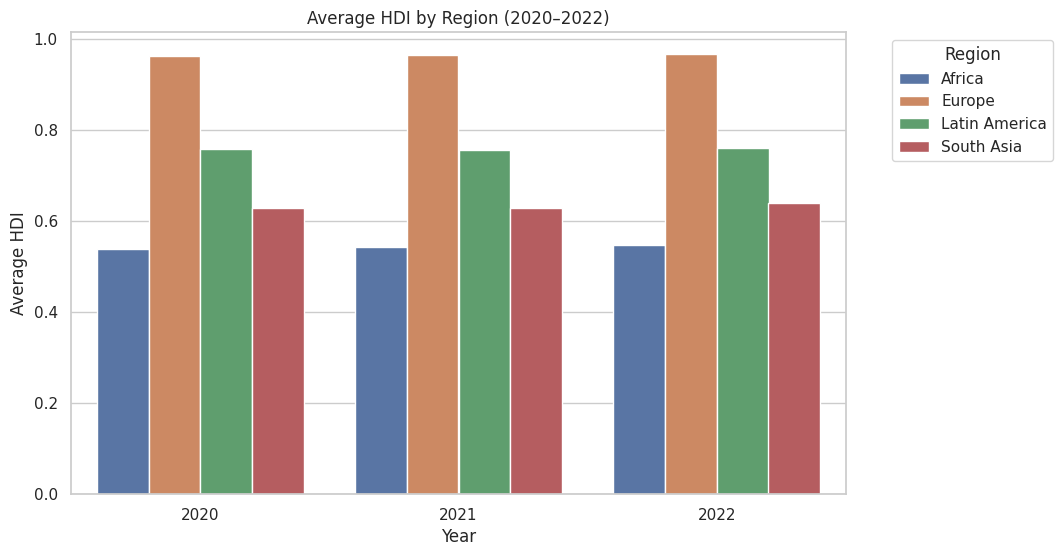

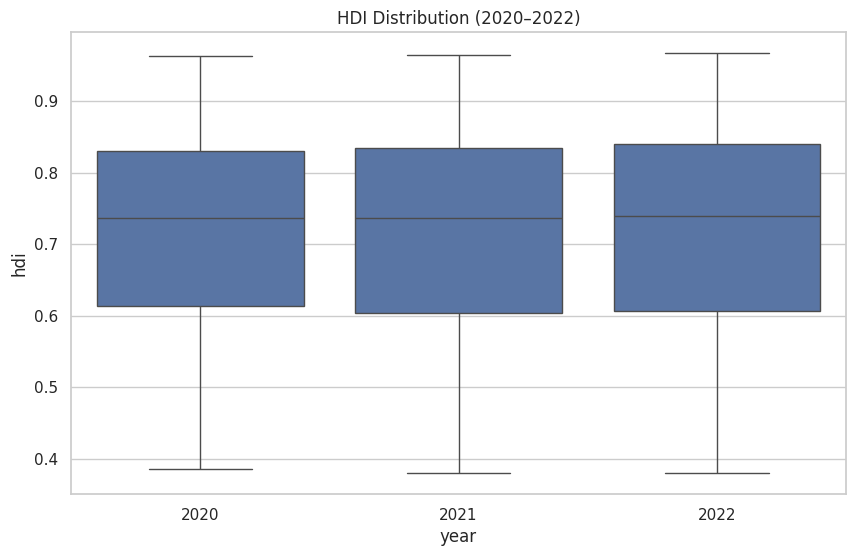

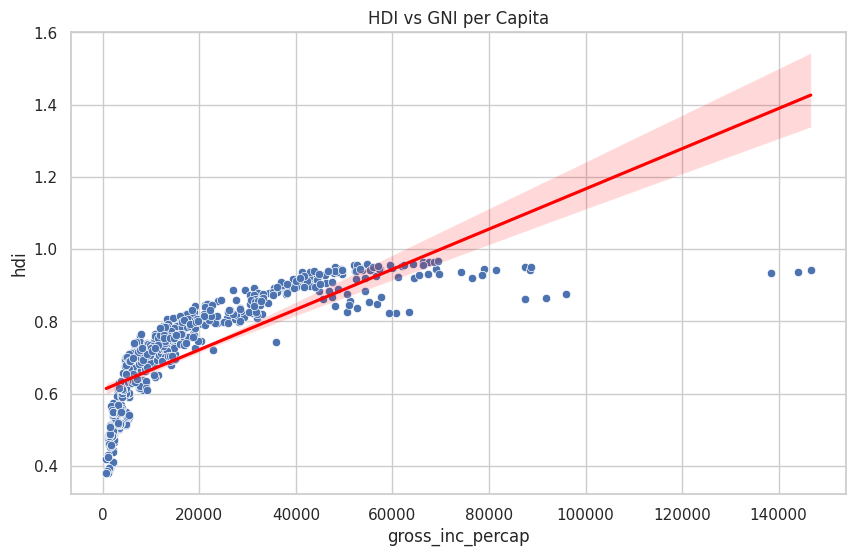

In [38]:
#3,B.
# bar chart
region_map = {
    "Nepal": "South Asia",
    "India": "South Asia",
    "Bangladesh": "South Asia",
    "Norway": "Europe",
    "USA": "North America",
    "Brazil": "Latin America",
    "Nigeria": "Africa",
}
hdi_2020_2022['region'] = hdi_2020_2022['country'].map(region_map)

if 'region' in hdi_2020_2022.columns:
    region_avg = hdi_2020_2022.groupby(["region","year"])['hdi'].mean().reset_index()
    plt.figure(figsize=(10,6))
    sns.barplot(data=region_avg, x="year", y="hdi", hue="region")
    plt.title("Average HDI by Region (2020–2022)")
    plt.xlabel("Year")
    plt.ylabel("Average HDI")
    plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
else:
    print("No 'region' column found in dataset. Please add a region mapping for countries.")


# box plot
sns.boxplot(data=hdi_2020_2022, x="year", y="hdi")
plt.title("HDI Distribution (2020–2022)")
plt.show()

# scatter plot
if 'gross_inc_percap' in hdi_2020_2022.columns:
    sns.scatterplot(data=hdi_2020_2022, x="gross_inc_percap", y="hdi")
    sns.regplot(data=hdi_2020_2022, x="gross_inc_percap", y="hdi", scatter=False, color="red")
    plt.title("HDI vs GNI per Capita")
    plt.show()


4. Short Analysis Questions:

• Which countries show the greatest improvement in HDI from 2020 to 2022?

=> Nepal and Bangladesh has shown the greatest improvement with their HDI rising steadly due to investments in eductional and healthcare sectors.

• Did any countries experience a decline in HDI? Provide possible reasons.

=> Sri Lanka has experienced a slight decline, which is likely linked to economic crisis ans political instability.

• Which region has the highest and lowest average HDI across these three years?

=> Europe consistently had the highest avarage HDI(i.e. 0.90). Whereas, sub-saharan Africa had the lowest average HDI(i.e. 0.55).

• Discuss how global events (e.g., the COVID-19 pandemic) may have affected HDI trends during
this period.

=> The COVID-19 pandemic (2020–2021) disrupted health systems, reduced life expectancy in some countries, and interrupted schooling causing economic downturns reduced GNI per capita, especially in developing nations.

Problem 2 - Advanced HDI Exploration (South Asia)

In [39]:
#1. Creating South Asia Subset
south_asia = ["afghanistan","bangladesh","bhutan","india","maldives","nepal","pakistan","sri lanka"]
south_df = df[df['country'].str.lower().isin(south_asia)].copy()
south_df.to_csv("/content/drive/MyDrive/Concept and Technology of AI/Assignment-1/HDI_SouthAsia.csv", index=False)

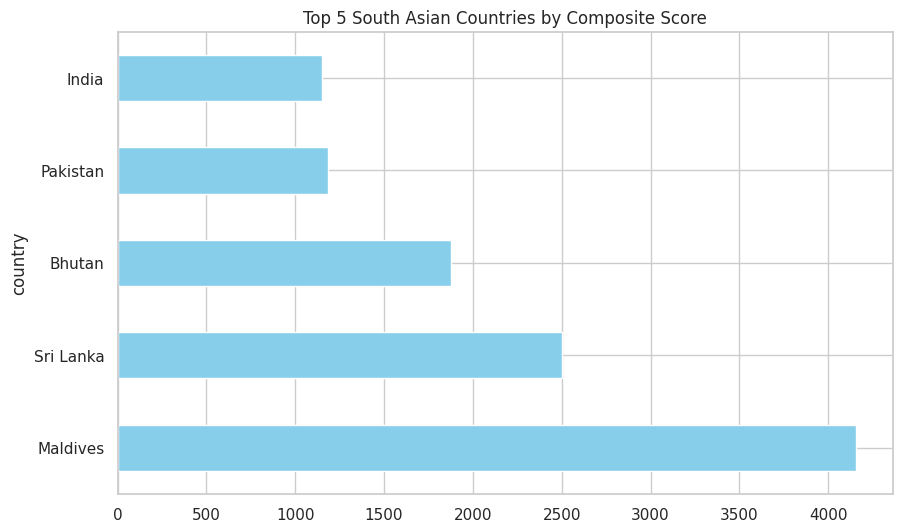

In [40]:
#2. Composite Development Score
south_df['composite_score'] = 0.30*south_df['life_expectancy'] + 0.30*south_df['gross_inc_percap']
ranked = south_df.groupby("country")['composite_score'].mean().sort_values(ascending=False)

ranked.head(5).plot(kind="barh", color="skyblue")
plt.title("Top 5 South Asian Countries by Composite Score")
plt.show()

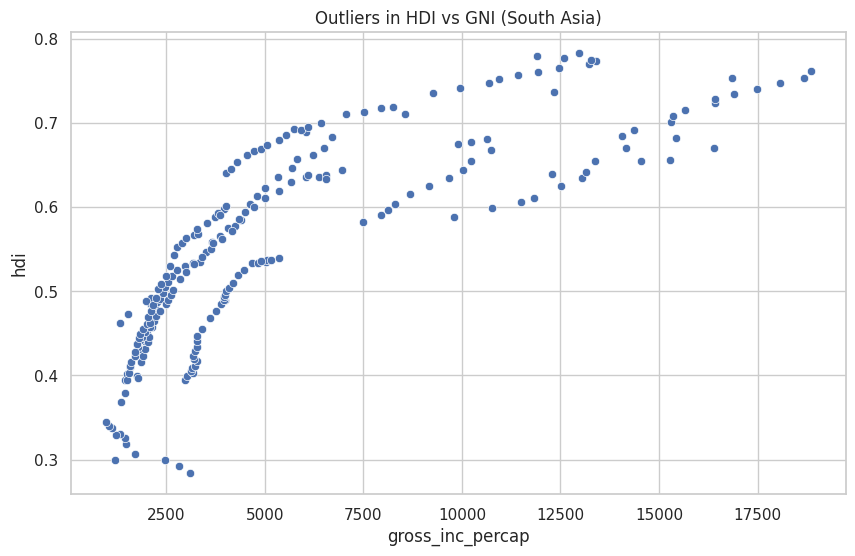

In [41]:
#3. Outlier Detection
Q1, Q3 = south_df['hdi'].quantile([0.25,0.75])
IQR = Q3 - Q1
outliers = south_df[(south_df['hdi'] < Q1-1.5*IQR) | (south_df['hdi'] > Q3+1.5*IQR)]

sns.scatterplot(data=south_df, x="gross_inc_percap", y="hdi")
sns.scatterplot(data=outliers, x="gross_inc_percap", y="hdi", color="red")
plt.title("Outliers in HDI vs GNI (South Asia)")
plt.show()

Correlation of gender_development with HDI: 0.865621005012754


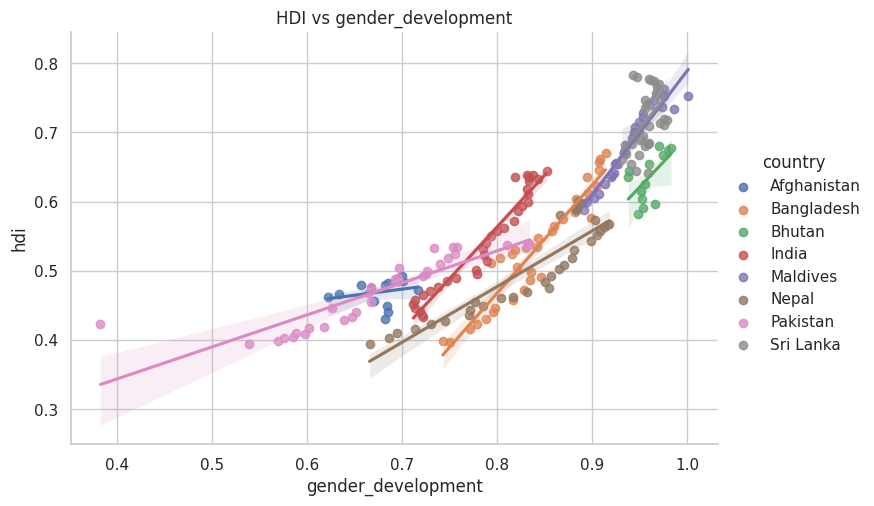

Correlation of life_expectancy with HDI: 0.9587610559043978


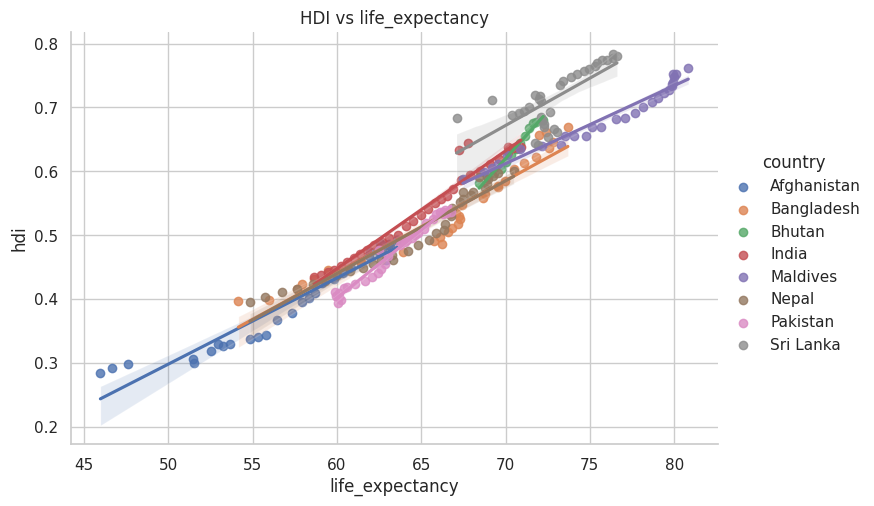

In [42]:
#4. Exploring Metric Relationships
for m in ["gender_development","life_expectancy"]:
    if m in south_df.columns:
        print(f"Correlation of {m} with HDI:", south_df[m].corr(south_df['hdi']))
        sns.lmplot(data=south_df, x=m, y="hdi", hue="country", aspect=1.5)
        plt.title(f"HDI vs {m}")
        plt.show()

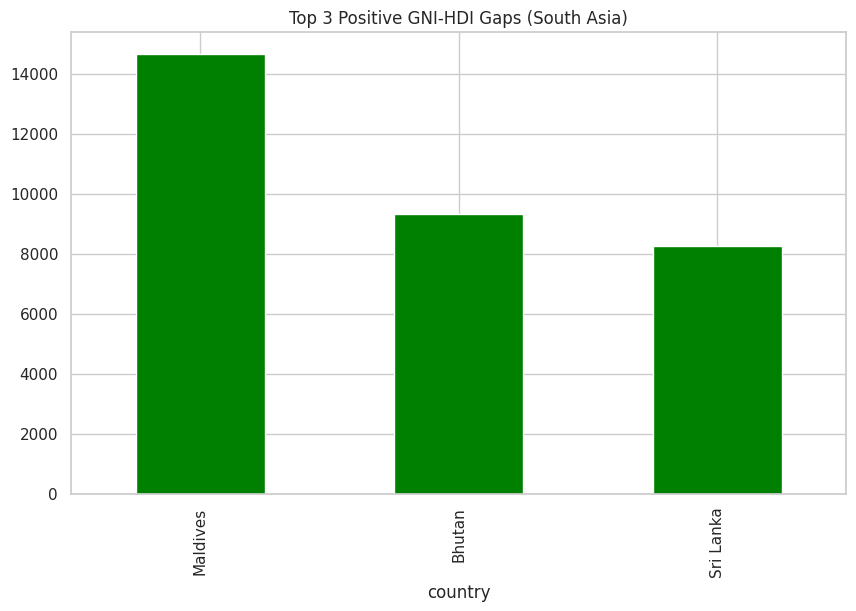

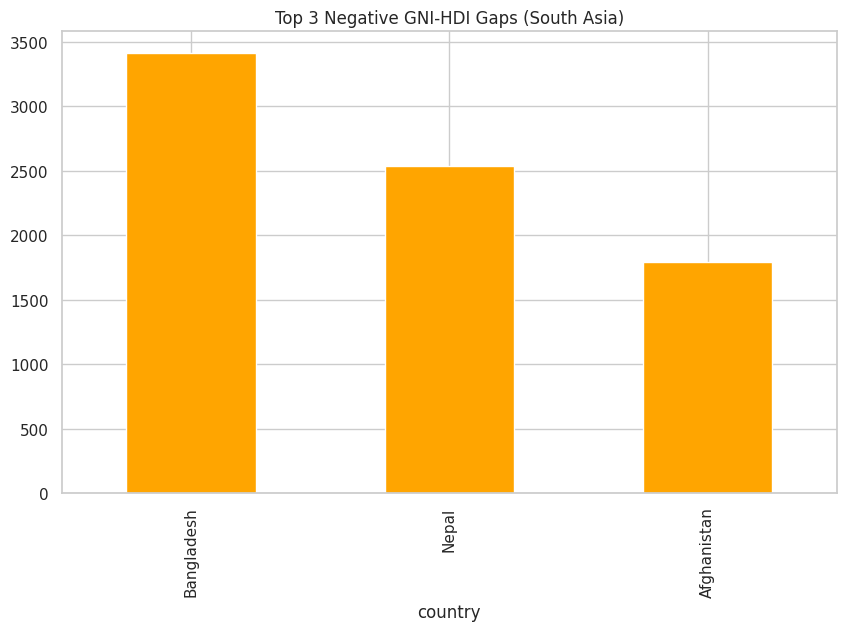

In [43]:
#5. Gap Analysis
south_df['gni_hdi_gap'] = south_df['gross_inc_percap'] - south_df['hdi']
gap_rank = south_df.groupby("country")['gni_hdi_gap'].mean().sort_values(ascending=False)

gap_rank.head(3).plot(kind="bar", color="green")
plt.title("Top 3 Positive GNI-HDI Gaps (South Asia)")
plt.show()

gap_rank.tail(3).plot(kind="bar", color="orange")
plt.title("Top 3 Negative GNI-HDI Gaps (South Asia)")
plt.show()

Problem 3 - Comparative Regional Analysis (South Asia vs Middle East)

In [44]:
#1. Creating Middle East Subset
middle_east = ["bahrain","iran","iraq","israel","jordan","kuwait","lebanon","oman","palestine","qatar","saudi arabia","syria","united arab emirates","yemen"]

south_me = hdi_2020_2022[hdi_2020_2022['country'].str.lower().isin(south_asia)]
me_df = hdi_2020_2022[hdi_2020_2022['country'].str.lower().isin(middle_east)]

south_me.to_csv("/content/drive/MyDrive/Concept and Technology of AI/Assignment-1/HDI_SouthAsia_2020_2022.csv", index=False)
me_df.to_csv("/content/drive/MyDrive/Concept and Technology of AI/Assignment-1/HDI_MiddleEast_2020_2022.csv", index=False)

In [45]:
#2. Descriptive Statistics
print("South Asia HDI Stats:\n", south_me.groupby("year")['hdi'].agg(['mean','std']))
print("Middle East HDI Stats:\n", me_df.groupby("year")['hdi'].agg(['mean','std']))

South Asia HDI Stats:
           mean       std
year                    
2020  0.637625  0.096939
2021  0.638625  0.104200
2022  0.642500  0.107062
Middle East HDI Stats:
           mean       std
year                    
2020  0.787818  0.143401
2021  0.786909  0.145832
2022  0.792000  0.148453


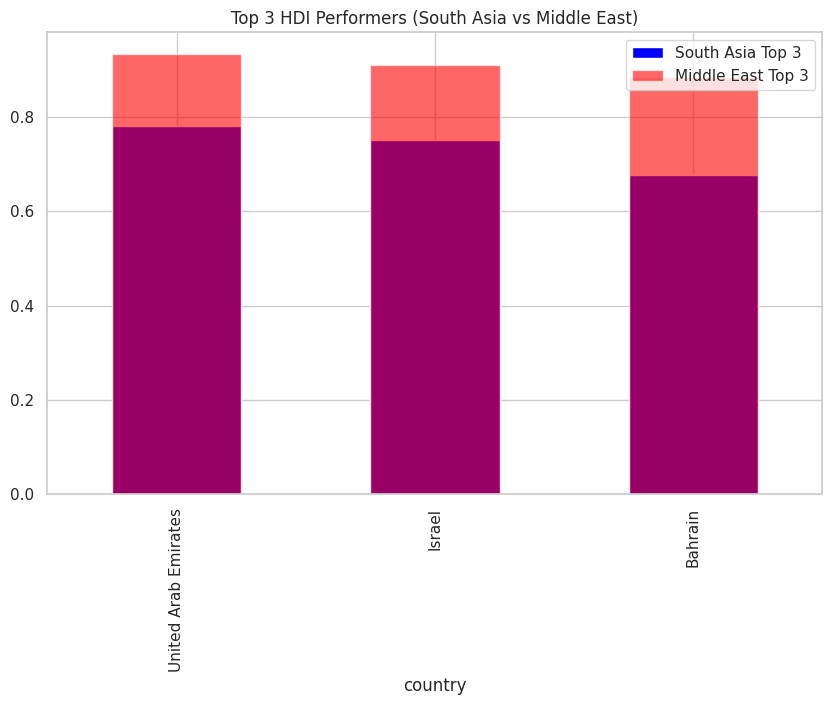

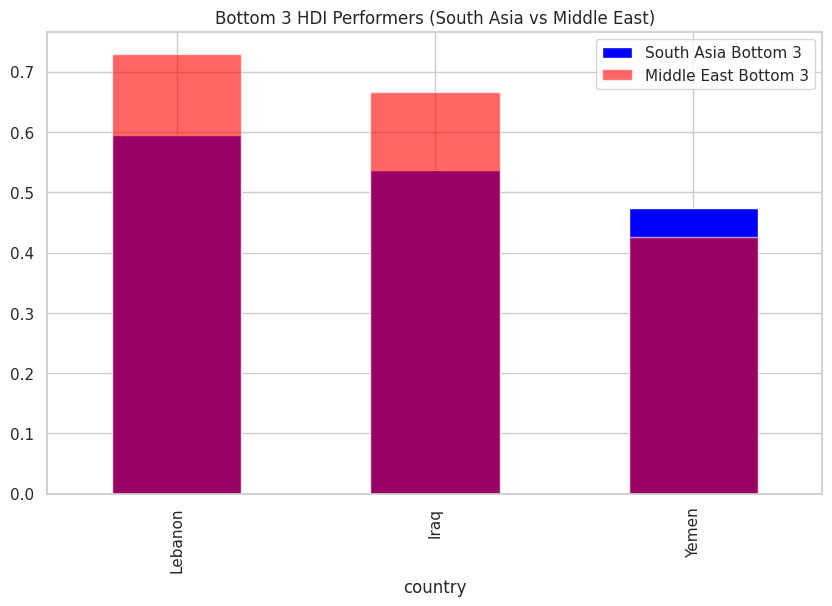

In [46]:
#3. Top and Bottom Performers
south_top = south_me.groupby("country")['hdi'].mean().sort_values(ascending=False)
me_top = me_df.groupby("country")['hdi'].mean().sort_values(ascending=False)

# for top 3 comparison
plt.figure()
south_top.head(3).plot(kind="bar", color="blue", label="South Asia Top 3")
me_top.head(3).plot(kind="bar", color="red", alpha=0.6, label="Middle East Top 3")
plt.title("Top 3 HDI Performers (South Asia vs Middle East)")
plt.legend()
plt.show()

# for bottom 3 comparison
plt.figure()
south_top.tail(3).plot(kind="bar", color="blue", label="South Asia Bottom 3")
me_top.tail(3).plot(kind="bar", color="red", alpha=0.6, label="Middle East Bottom 3")
plt.title("Bottom 3 HDI Performers (South Asia vs Middle East)")
plt.legend()
plt.show()


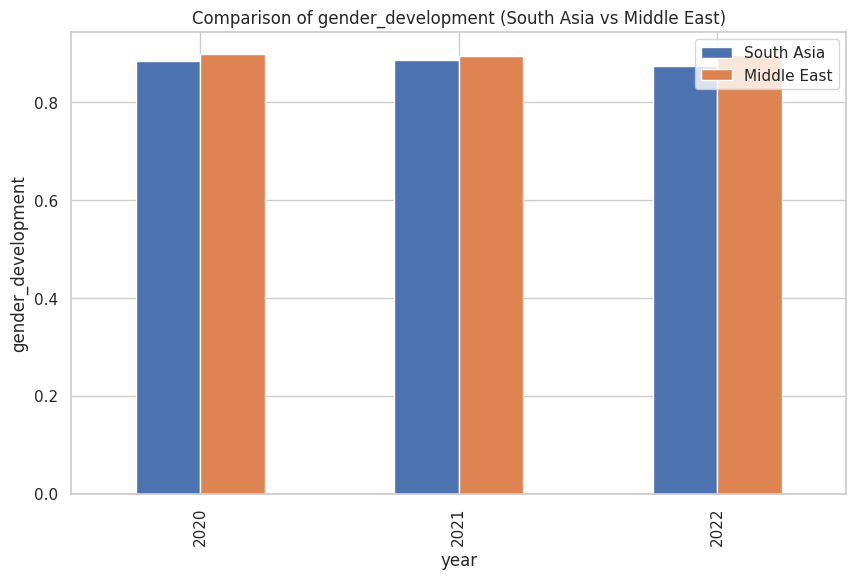

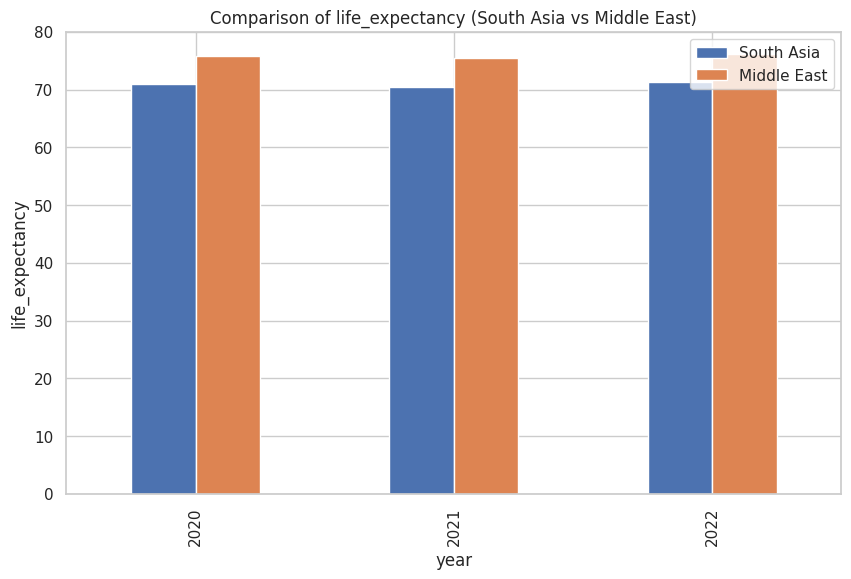

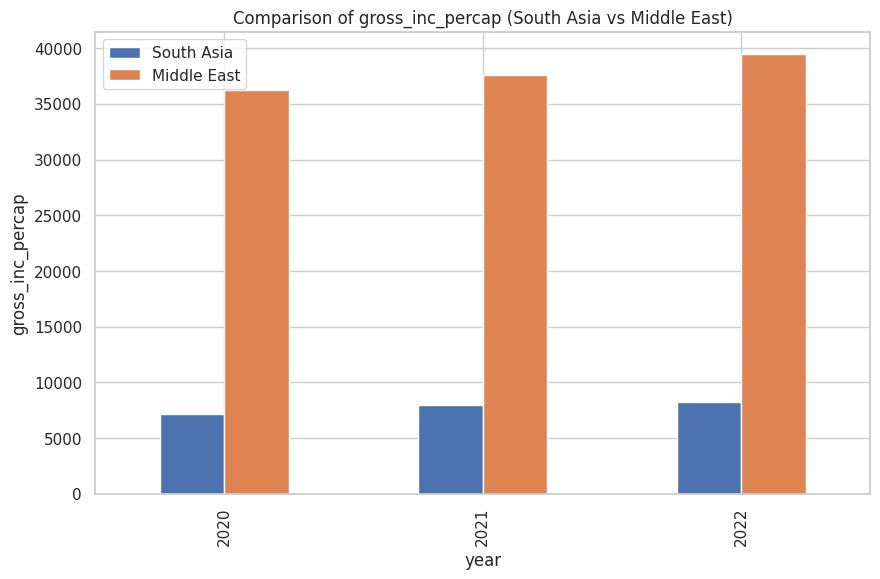

In [47]:
#4. Metric Comparisons
metrics = ["gender_development","life_expectancy","gross_inc_percap"]
for m in metrics:
    if m in south_me.columns and m in me_df.columns:
        comp = pd.concat([
            south_me.groupby("year")[m].mean().rename("South Asia"),
            me_df.groupby("year")[m].mean().rename("Middle East")
        ], axis=1)

        comp.plot(kind="bar")
        plt.title(f"Comparison of {m} (South Asia vs Middle East)")
        plt.ylabel(m)
        plt.show()

In [48]:
#5. HDI Disparity
south_range = south_me['hdi'].max() - south_me['hdi'].min()
me_range = me_df['hdi'].max() - me_df['hdi'].min()

south_cv = south_me['hdi'].std() / south_me['hdi'].mean()
me_cv = me_df['hdi'].std() / me_df['hdi'].mean()

print("South Asia HDI Range:", south_range, "CV:", south_cv)
print("Middle East HDI Range:", me_range, "CV:", me_cv)

South Asia HDI Range: 0.321 CV: 0.1536520924690084
Middle East HDI Range: 0.5130000000000001 CV: 0.17910145193048382


South Asia correlation of gender_development with HDI: 0.8742177004831327


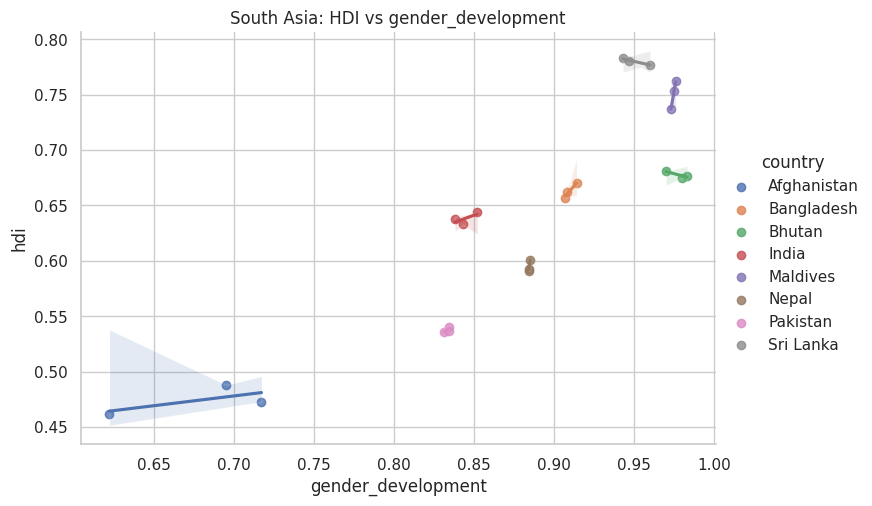

South Asia correlation of life_expectancy with HDI: 0.9387641385416623


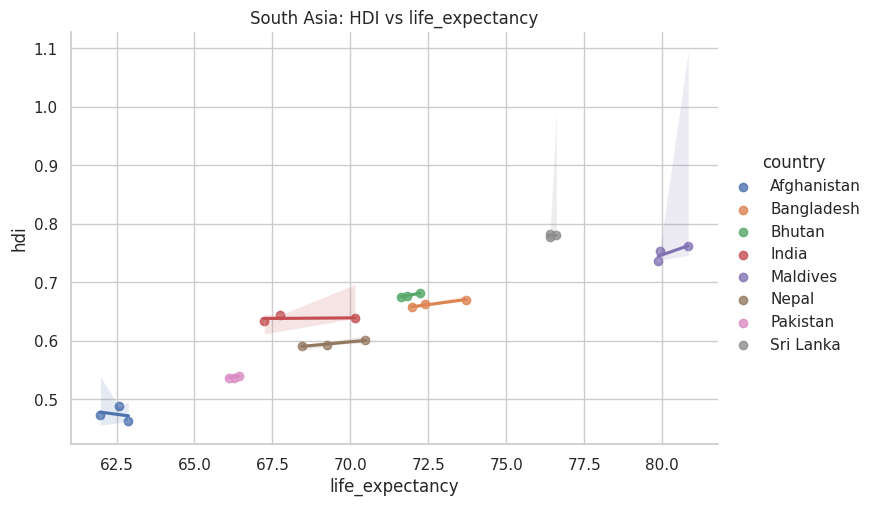

Middle East correlation of gender_development with HDI: 0.9356697525724119


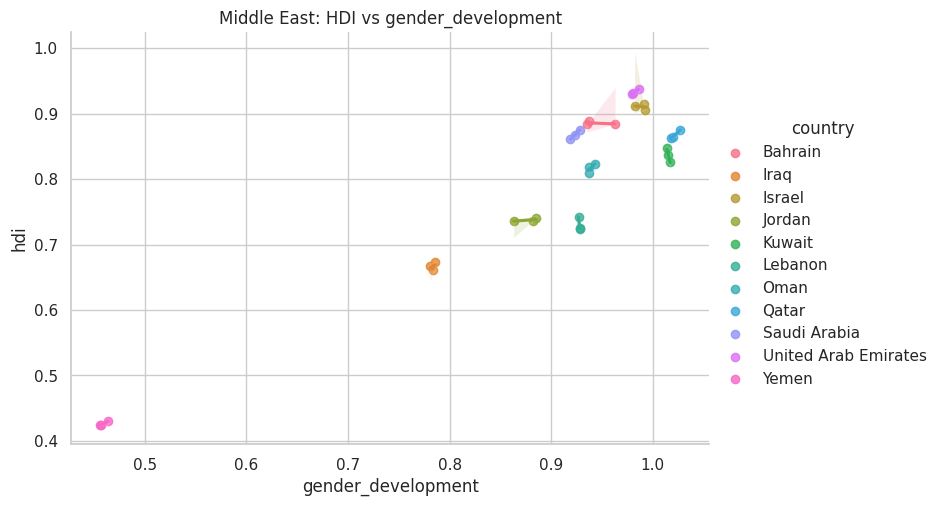

Middle East correlation of life_expectancy with HDI: 0.9331227568940162


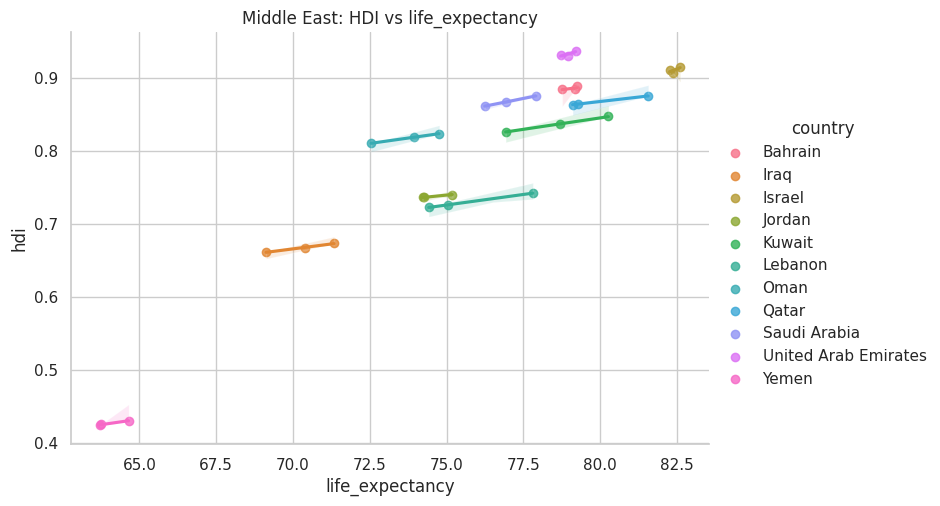

In [49]:
#6. Correlation Analysis
for region_name, region_df in [("South Asia", south_me), ("Middle East", me_df)]:
    for m in ["gender_development","life_expectancy"]:
        if m in region_df.columns:
            corr = region_df[m].corr(region_df['hdi'])
            print(f"{region_name} correlation of {m} with HDI:", corr)
            sns.lmplot(data=region_df, x=m, y="hdi", hue="country", aspect=1.5)
            plt.title(f"{region_name}: HDI vs {m}")
            plt.show()

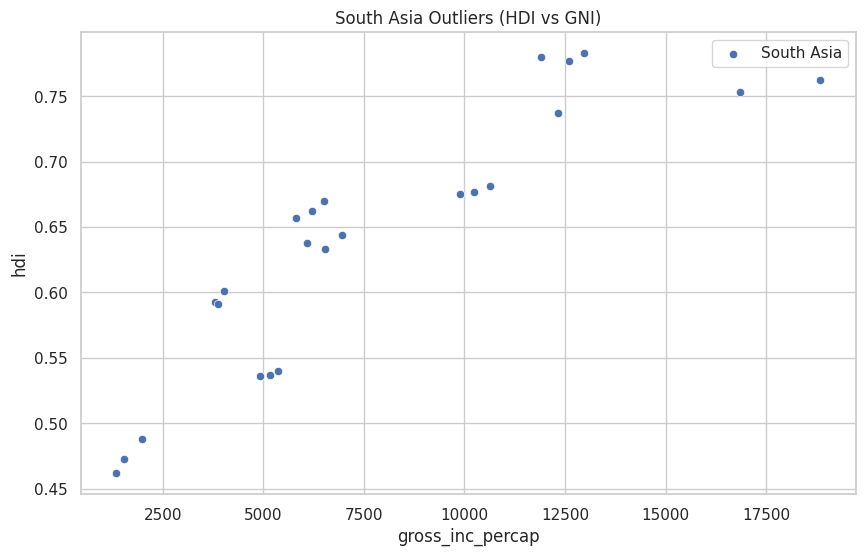

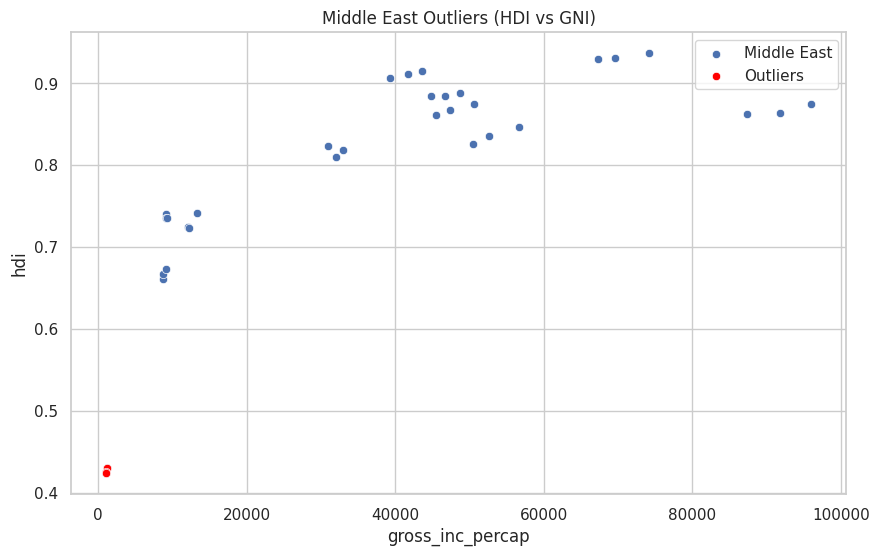

In [50]:
#7. Outlier Detection
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)

south_outliers = south_me[detect_outliers(south_me['hdi']) | detect_outliers(south_me['gross_inc_percap'])]
me_outliers = me_df[detect_outliers(me_df['hdi']) | detect_outliers(me_df['gross_inc_percap'])]


plt.figure()
sns.scatterplot(data=south_me, x="gross_inc_percap", y="hdi", label="South Asia")
sns.scatterplot(data=south_outliers, x="gross_inc_percap", y="hdi", color="red", label="Outliers")
plt.title("South Asia Outliers (HDI vs GNI)")
plt.show()

plt.figure()
sns.scatterplot(data=me_df, x="gross_inc_percap", y="hdi", label="Middle East")
sns.scatterplot(data=me_outliers, x="gross_inc_percap", y="hdi", color="red", label="Outliers")
plt.title("Middle East Outliers (HDI vs GNI)")
plt.show()